In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import time

## 3. Implement GD, Polyak GD, Nesterov GD, and AdaGrad GD.

* GD: xk+1 = xk−γ∇f (xk )
* Polyak: xk+1 = xk−γ∇f (xk ) + µ(xk−xk−1)
* Nesterov: xk+1 = xk−γ∇f xk + µ(xk−xk−1) + µ(xk−xk−1)
* AdaGrad: xk+1 = xk−γDk ·∇f (xk )

In [2]:
#NUMERICAL helpers

def get_grad(f, x, eps=1e-5):
    """Numeric gradient fallback if analytical is not provided."""
    g = np.zeros_like(x)
    for i in range(len(x)):
        x1, x2 = x.copy(), x.copy()
        x1[i] += eps; x2[i] -= eps
        g[i] = (f(x1) - f(x2)) / (2 * eps)
    return g

In [3]:
def run_gd(x1, f, n_steps, gamma, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        x = x - gamma * grad(x)
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

def run_polyak_gd(x1, f, n_steps, gamma, mu, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    x_prev = x.copy()
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        x_next = x - gamma * grad(x) + mu * (x - x_prev)
        x_prev = x.copy()
        x = x_next.copy()
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

def run_nesterov_gd(x1, f, n_steps, gamma, mu, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    x_prev = x.copy()
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        lookahead = x + mu * (x - x_prev)
        x_next = lookahead - gamma * grad(lookahead)
        x_prev = x.copy()
        x = x_next.copy()
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

def run_adagrad(x1, f, n_steps, gamma, eps=1e-8, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    sq_grad_sum = np.zeros_like(x)
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        g = grad(x)
        sq_grad_sum += g**2
        x = x - (gamma / (np.sqrt(sq_grad_sum) + eps)) * g
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

## 4. Find, describe, and implement Adam GD.

Adam (Adaptive Moment Estimation) combines the heavy-ball momentum from Polyak/Nesterov with the adaptive, coordinate-wise scaling of AdaGrad/RMSProp.  Instead of just adapting the learning rate based on the sum of past squared gradients (like AdaGrad, which eventually dampens the process too much ), Adam keeps an exponentially decaying average of past squared gradients. It also keeps an exponentially decaying average of past gradients (like momentum).

At each step k it calculates:
* First moment (mean): $m_k = \beta_1 m_{k-1} + (1 - \beta_1) \nabla f(x_{k-1})$
* Second moment (var): $v_k = \beta_2 v_{k-1} + (1 - \beta_2) (\nabla f(x_{k-1}))^2$

Bias correction step (to fix biasness toward 0):
* $\hat{m}_k = \frac{m_k}{1 - \beta_1^k}$
* $\hat{v}_k = \frac{v_k}{1 - \beta_2^k}$

Update rule:
$x_k = x_{k-1} - \gamma \frac{\hat{m}_k}{\sqrt{\hat{v}_k} + \epsilon}$

Params:
* $\gamma$ - global LR (npr 0.001)
* $\beta_1$ - exponential decay rate for first moment (npr 0.9)
* $\beta_2$ - exponential decay rate for second moment (npr 0.999)
* $\epsilon$ - prevent divison by 0

In [4]:
def run_adam(x1, f, n_steps, gamma=0.1, beta1=0.9, beta2=0.999, eps=1e-8, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for k in range(1, n_steps + 1):
        g = grad(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g**2)
        
        m_hat = m / (1 - beta1**k)
        v_hat = v / (1 - beta2**k)
        
        x = x - gamma * m_hat / (np.sqrt(v_hat) + eps)
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

## 5. Implement the Newton method and BFGS

NEWTON: $x_{k+1} = x_k - (\nabla^2 f(x_k))^{-1} \nabla f(x_k)$ 

BFGS: $B_{k+1} = B_k - \frac{\delta \gamma^T B_k + B_k \gamma \delta^T}{\delta^T \gamma} + \left(1 + \frac{\gamma^T B_k \gamma}{\delta^T \gamma}\right) \frac{\delta \delta^T}{\delta^T \gamma}$   

In [5]:
#NUMERIC helpers

def get_hess(f, x, eps=1e-5):
    """Numeric Hessian fallback with positive-definite adjustment."""
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x1, x2, x3, x4 = x.copy(), x.copy(), x.copy(), x.copy()
            x1[i] += eps; x1[j] += eps
            x2[i] += eps; x2[j] -= eps
            x3[i] -= eps; x3[j] += eps
            x4[i] -= eps; x4[j] -= eps
            H[i,j] = (f(x1) - f(x2) - f(x3) + f(x4)) / (4 * eps * eps)
    
    # Ensure Positive Definiteness
    eigvals = np.linalg.eigvalsh(H)
    if np.any(eigvals <= 0):
        H += (abs(np.min(eigvals)) + 1e-4) * np.eye(n)
    return H

def line_search(f, x, direction, grad, c=1e-4, rho=0.5):
    """Armijo condition backtracking line search."""
    alpha = 1.0
    while f(x + alpha * direction) > f(x) + c * alpha * np.dot(grad, direction):
        alpha *= rho
        if alpha < 1e-8: break # prevent infinite loops
    return alpha

In [6]:
def run_newton(x1, f, n_steps, grad=None, hess=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    if hess is None: hess = lambda x: get_hess(f, x)
    x = np.array(x1, dtype=float)
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        g = grad(x)
        if np.linalg.norm(g) < 1e-8: break
        
        H = hess(x)
        direction = -np.linalg.solve(H, g)
        alpha = line_search(f, x, direction, g)
        
        x = x + alpha * direction
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

def run_bfgs(x1, f, n_steps, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    n = len(x)
    B = np.eye(n) # Initial inverse Hessian approx
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        g = grad(x)
        if np.linalg.norm(g) < 1e-8: break
            
        direction = -np.dot(B, g)
        alpha = line_search(f, x, direction, g)
        
        x_next = x + alpha * direction
        g_next = grad(x_next)
        
        delta = x_next - x
        gamma_vec = g_next - g
        denom = np.dot(delta, gamma_vec)
        
        if denom > 1e-10:
            term1 = (np.outer(delta, gamma_vec) @ B + B @ np.outer(gamma_vec, delta)) / denom
            scalar = 1.0 + np.dot(gamma_vec, B @ gamma_vec) / denom
            term2 = scalar * (np.outer(delta, delta) / denom)
            B = B - term1 + term2
            
        x = x_next.copy()
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

## 3 + 4 + 5: Sanity check
We will test these algorithms on the quadratic $f(x,y) = x^2 + 5y^2$. 

In [ ]:
def f_test(v):
    return v[0]**2 + 5 * v[1]**2

def grad_f_test(v):
    return np.array([2 * v[0], 10 * v[1]])

def hess_f_test(v):
    return np.array([[2, 0], [0, 10]])

# Initial settings
x0 = [1.0, 1.0]
N_STEPS = 10

# Optimal Theoretical Parameters (alpha=2, beta=10)
kappa = 10.0 / 2.0
g_gd = 1/6
g_pol = 4 / (np.sqrt(2) + np.sqrt(10))**2
m_pol = ((np.sqrt(10) - np.sqrt(2)) / (np.sqrt(10) + np.sqrt(2)))**2
g_nest = 1 / 10
m_nest = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)

# Execute all methods
results = {}
results['GD']       = run_gd(x0, f_test, N_STEPS, gamma=g_gd, grad=grad_f_test)
results['Polyak']   = run_polyak_gd(x0, f_test, N_STEPS, gamma=g_pol, mu=m_pol, grad=grad_f_test)
results['Nesterov'] = run_nesterov_gd(x0, f_test, N_STEPS, gamma=g_nest, mu=m_nest, grad=grad_f_test)
results['AdaGrad']  = run_adagrad(x0, f_test, N_STEPS, gamma=1.0, grad=grad_f_test)
results['Adam']     = run_adam(x0, f_test, N_STEPS, gamma=0.5, grad=grad_f_test)
results['Adam_100steps'] = run_adam(x0, f_test, 100, gamma=0.5, grad=grad_f_test) #want to test with more steps since 10 steps gave a poor result
results['BFGS']     = run_bfgs(x0, f_test, N_STEPS, grad=grad_f_test)
results['Newton']   = run_newton(x0, f_test, N_STEPS, grad=grad_f_test, hess=hess_f_test)

# Print Summary Table
print("=" * 65)
print(f" {'Method':<12} | {'Final x, y':<25} | {'Final f(x,y)'}")
print("-" * 65)
for name, (x_hist, f_hist) in results.items():
    final_x = x_hist[-1]
    final_f = f_hist[-1]
    coords = f"[{final_x[0]:.6f}, {final_x[1]:.6f}]"
    print(f" {name:<12} | {coords:<25} | {final_f:.10f}")
print("=" * 65)

 Method       | Final x, y                | Final f(x,y)
-----------------------------------------------------------------
 GD           | [0.017342, 0.017342]      | 0.0018043720
 Polyak       | [0.000475, 0.000980]      | 0.0000050242
 Nesterov     | [0.014579, 0.000000]      | 0.0002125499
 AdaGrad      | [0.000000, 0.000000]      | 0.0000000000
 Adam         | [0.180338, 0.180338]      | 0.1951307951
 Adam_100steps | [-0.004346, -0.004346]    | 0.0001133174
 BFGS         | [-0.000000, 0.000000]     | 0.0000000000
 Newton       | [0.000000, 0.000000]      | 0.0000000000


**TEST:** on function $f(x,y)=x^2 + 5y^2$ with minimum at (0,0)... the same function as in the notes (fig 15,16)

**GRADIENT:** $\nabla f(x,y) = (2x, 10y)$. The Hessian has eigenvalues $\alpha = 2$ and $\beta = 10$.

**GD param:** optimal LR for a quadratic is $\gamma = \frac{2}{\alpha + \beta} = \frac{2}{12} \approx 0.166$.  

**Polyak params:** $\gamma = \frac{4}{(\sqrt{\alpha} + \sqrt{\beta})^2}$ and $\mu = \left(\frac{\sqrt{\beta} - \sqrt{\alpha}}{\sqrt{\beta} + \sqrt{\alpha}}\right)^2$. So we get $\gamma \approx 0.19$ and $\mu \approx 0.15$

**Nesterov params:** $\gamma = \frac{1}{\beta}$ and $\mu = \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}$, where $\kappa = \frac{\beta}{\alpha}$... (theorem 5.3). So this gives us $\gamma = 0.1$ and $\mu \approx 0.382$

**AdaGrad param:** standard learning rate ($\gamma = 1.0$) because AdaGrad independently weights each coordinate by accumulating past gradients, meaning it adapts its own step size.

**Adam:**  use LR of 0.5 for faster convergence on this simple quadratic


## 6. Compare Mmethods 3, 4, 5
We will now compare all implementations across three distinct landscapes:
* (a) A 3D Quadratic Bowl: $f(x,y,z) = (x-z)^2 + (2y+z)^2 + (4x-2y+z)^2 + x + y$
* (b) 3D Rosenbrock Function: Non-convex and notoriously ill-conditioned ("banana valley").
* (c) Beale Function: A 2D non-convex function with sharp peaks and flat valleys.

We will measure performance first by **Iteration Count (Steps)** and then by **Computational Cost (Wall-clock time)**.

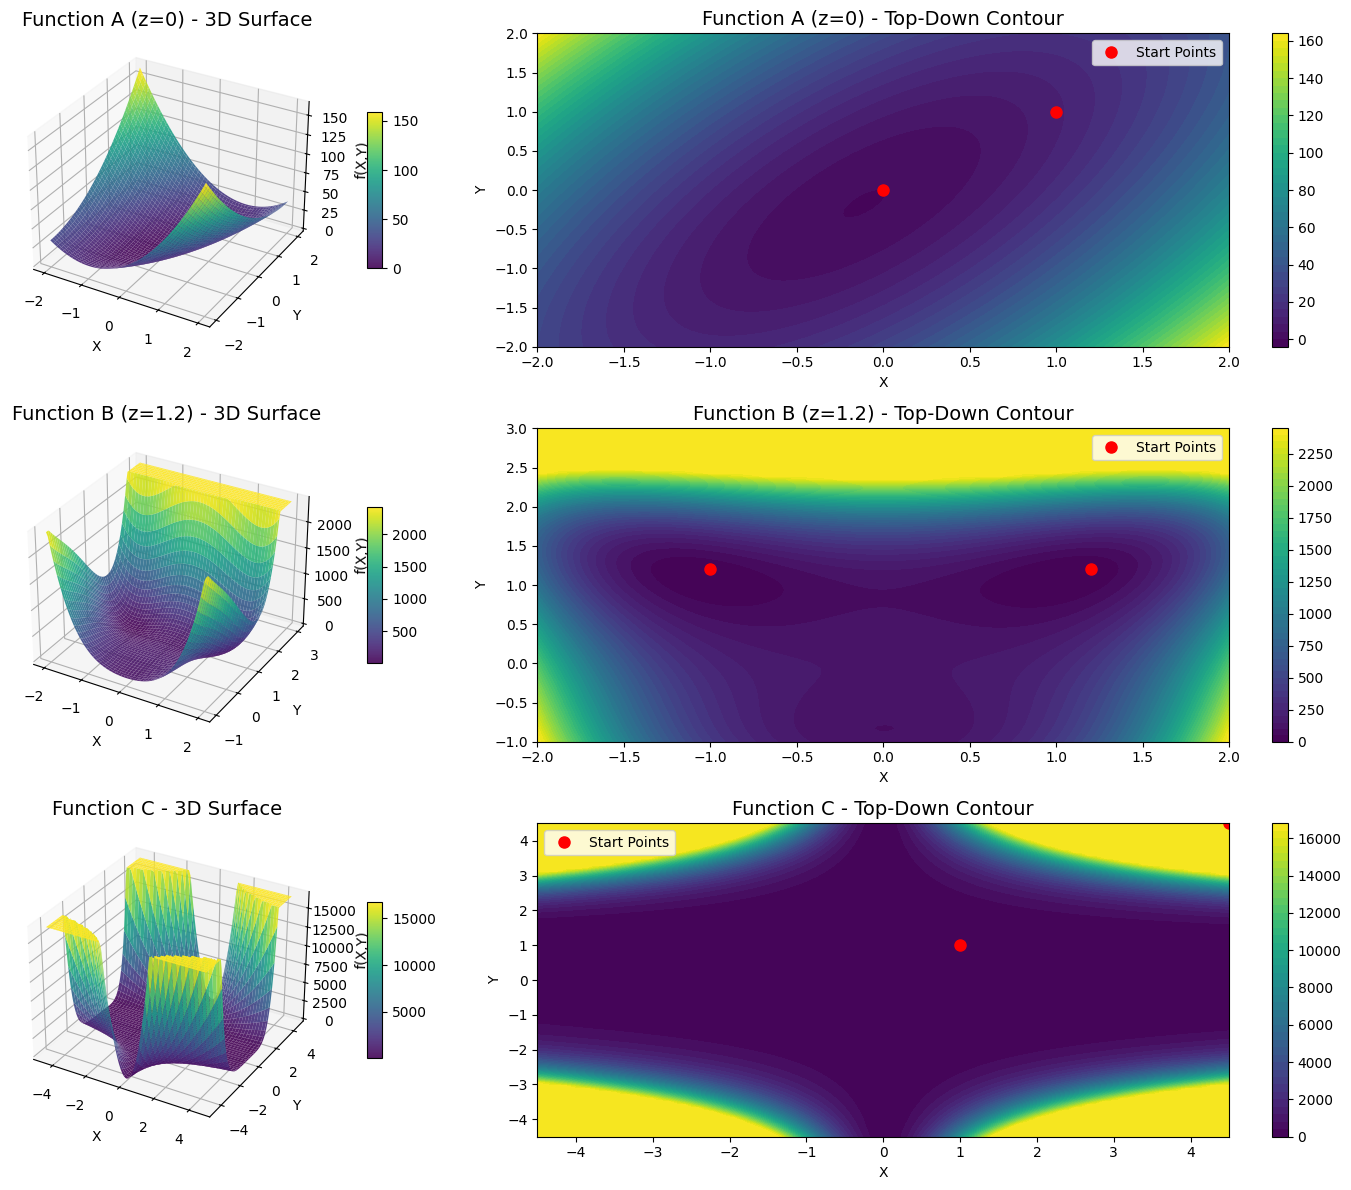

In [14]:
def plot_func_a(x, y, z=0):
    return (x - z)**2 + (2*y + z)**2 + (4*x - 2*y + z)**2 + x + y

def plot_func_b(x, y, z=1.2): 
    return (x - 1)**2 + (y - 1)**2 + 100*(y - x**2)**2 + 100*(z - y**2)**2

def plot_func_c(x, y):
    return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2


grids = {
    "Function A (z=0)": (np.linspace(-2, 2, 100), np.linspace(-2, 2, 100), plot_func_a),
    "Function B (z=1.2)": (np.linspace(-2, 2, 100), np.linspace(-1, 3, 100), plot_func_b),
    "Function C": (np.linspace(-4.5, 4.5, 100), np.linspace(-4.5, 4.5, 100), plot_func_c)
}

fig = plt.figure(figsize=(18, 12))

plot_idx = 1
for title, (x_range, y_range, func) in grids.items():
    X, Y = np.meshgrid(x_range, y_range)
    Z = func(X, Y)
    
    # Clip extreme values for B and C so the plots don't stretch to infinity
    if "B" in title or "C" in title:
        Z = np.clip(Z, 0, np.percentile(Z, 85))
    
    # 3D Surface Plot
    ax3d = fig.add_subplot(3, 2, plot_idx, projection='3d')
    surf = ax3d.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor='none', alpha=0.9)
    ax3d.set_title(f"{title} - 3D Surface", fontsize=14)
    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('f(X,Y)')
    fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10)
    
    # 2D Contour Plot (Top-down view of the gradients)
    ax2d = fig.add_subplot(3, 2, plot_idx + 1)
    contour = ax2d.contourf(X, Y, Z, levels=50, cmap=cm.viridis)
    ax2d.set_title(f"{title} - Top-Down Contour", fontsize=14)
    ax2d.set_xlabel('X')
    ax2d.set_ylabel('Y')
    fig.colorbar(contour, ax=ax2d)
    
    if "Function A" in title:
        ax2d.plot([0, 1], [0, 1], 'ro', markersize=8, label='Start Points')
    elif "Function B" in title:
        ax2d.plot([1.2, -1], [1.2, 1.2], 'ro', markersize=8, label='Start Points')
    elif "Function C" in title:
        ax2d.plot([1, 4.5], [1, 4.5], 'ro', markersize=8, label='Start Points')
    
    ax2d.legend()
    plot_idx += 2

plt.tight_layout()
plt.show()

In [7]:
# A
def f_a(p):
    x, y, z = p
    return (x - z)**2 + (2*y + z)**2 + (4*x - 2*y + z)**2 + x + y

def grad_f_a(p):
    x, y, z = p
    r1, r2, r3 = (x - z), (2*y + z), (4*x - 2*y + z)
    return np.array([
        2*r1 + 8*r3 + 1,
        4*r2 - 4*r3 + 1,
        -2*r1 + 2*r2 + 2*r3
    ])

def hess_f_a(p):
    # Constant Hessian since the function is purely quadratic
    return np.array([
        [34.0, -16.0,  6.0],
        [-16.0, 16.0,  0.0],
        [ 6.0,   0.0,  6.0]
    ])

STARTS_A = [np.array([0.0, 0.0, 0.0]), np.array([1.0, 1.0, 0.0])]

# B
def f_b(p):
    x, y, z = p
    return (x-1)**2 + (y-1)**2 + 100*(y - x**2)**2 + 100*(z - y**2)**2

def grad_f_b(p):
    x, y, z = p
    u, v = (y - x**2), (z - y**2)
    return np.array([
        2*(x-1) - 400*x*u,
        2*(y-1) + 200*u - 400*y*v,
        200*v
    ])

def hess_f_b(p):
    x, y, z = p
    u, v = (y - x**2), (z - y**2)
    return np.array([
        [2 - 400*u + 800*x**2, -400*x,               0.0],
        [-400*x,               202 - 400*v + 800*y**2, -400*y],
        [0.0,                  -400*y,               200.0]
    ])

STARTS_B = [np.array([1.2, 1.2, 1.2]), np.array([-1.0, 1.2, 1.2])]

# C
def f_c(p):
    x, y = p
    return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

def grad_f_c(p):
    x, y = p
    r1, r2, r3 = (1.5 - x + x*y), (2.25 - x + x*y**2), (2.625 - x + x*y**3)
    return np.array([
        2*r1*(y-1) + 2*r2*(y**2-1) + 2*r3*(y**3-1),
        2*r1*x + 2*r2*(2*x*y) + 2*r3*(3*x*y**2)
    ])

def hess_f_c(p):
    x, y = p
    r1, r2, r3 = (1.5 - x + x*y), (2.25 - x + x*y**2), (2.625 - x + x*y**3)
    H_xx = 2*(y-1)**2 + 2*(y**2-1)**2 + 2*(y**3-1)**2
    H_yy = 2*x**2 + 2*(2*x*y)**2 + 4*x*r2 + 2*(3*x*y**2)**2 + 12*x*y*r3
    H_xy = 2*(y-1)*x + 2*r1 + 2*(y**2-1)*2*x*y + 4*y*r2 + 2*(y**3-1)*3*x*y**2 + 6*y**2*r3
    return np.array([[H_xx, H_xy], [H_xy, H_yy]])

STARTS_C = [np.array([1.0, 1.0]), np.array([4.5, 4.5])]

In [ ]:
#EVAL
METHODS = [
    ("GD",       lambda x, f, g, H, n: run_gd(x, f, n, gamma=0.001, grad=g)),
    ("Polyak",   lambda x, f, g, H, n: run_polyak_gd(x, f, n, gamma=0.001, mu=0.9, grad=g)),
    ("Nesterov", lambda x, f, g, H, n: run_nesterov_gd(x, f, n, gamma=0.001, mu=0.9, grad=g)),
    ("AdaGrad",  lambda x, f, g, H, n: run_adagrad(x, f, n, gamma=0.5, grad=g)),
    ("Adam",     lambda x, f, g, H, n: run_adam(x, f, n, gamma=0.1, grad=g)),
    ("BFGS",     lambda x, f, g, H, n: run_bfgs(x, f, n, grad=g)),
    ("Newton",   lambda x, f, g, H, n: run_newton(x, f, n, grad=g, hess=H)),
]

FUNCTIONS = [
    ("1 3D Quadratic", f_a, grad_f_a, hess_f_a, STARTS_A),
    ("2 3D Rosenbrock",   f_b, grad_f_b, hess_f_b, STARTS_B),
    ("3 Beale",        f_c, grad_f_c, hess_f_c, STARTS_C),
]

STEP_CHECKS = [2, 5, 10, 100]
TIME_CHECKS = [0.1, 1.0, 2.0]

def format_f(val):
    if not np.isfinite(val): return "diverged"
    if abs(val) < 1e-8: return f"{val:.2e}"
    return f"{val:.6f}"

def print_ranking(results_row, label):
    """Sorts and prints the top 3 methods."""
    valid = [(name, v) for name, v in results_row if np.isfinite(v)]
    invalid = [(name, v) for name, v in results_row if not np.isfinite(v)]
    ranked = sorted(valid, key=lambda t: t[1]) + invalid
    
    parts = [f"{i+1}. {name} ({format_f(v)})" for i, (name, v) in enumerate(ranked[:3])]
    print(f"    {label}: {',  '.join(parts)}")

# ------------------------------------------------------------
# PART (a) - STEPS
# ------------------------------------------------------------
print("=" * 80)
print("PART (a): PERFORMANCE BY NUMBER OF STEPS")
print("=" * 80)

for fn_label, f, grad, hess, starts in FUNCTIONS:
    print(f"\n[{fn_label}]")
    for x1 in starts:
        print(f"\n  Starting point: {x1}")
        print(f"  {'Method':<12}" + "".join([f"{k:>12} steps" for k in STEP_CHECKS]))
        print("  " + "-" * 60)
        
        step_results = {name: {} for name, _ in METHODS}
        for name, run_fn in METHODS:
            print(f"  {name:<12}", end="")
            for n_steps in STEP_CHECKS:
                try:
                    _, f_hist = run_fn(x1, f, grad, hess, n_steps)
                    val = f_hist[-1]
                except Exception:
                    val = np.inf
                    
                step_results[name][n_steps] = val if np.isfinite(val) else np.inf
                print(f"{format_f(step_results[name][n_steps]):>18}", end="")
            print()
            
        print()
        for n_steps in STEP_CHECKS:
            row = [(name, step_results[name][n_steps]) for name, _ in METHODS]
            print_ranking(row, f"{n_steps:>3} steps")

# ------------------------------------------------------------
# PART (b) - TIME
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("PART (b): PERFORMANCE BY WALL-CLOCK TIME")
print("=" * 80)

for fn_label, f, grad, hess, starts in FUNCTIONS:
    print(f"\n[{fn_label}]")
    for x1 in starts:
        print(f"\n  Starting point: {x1}")
        print(f"  {'Method':<12}" + "".join([f"{t:>10.1f}s" for t in TIME_CHECKS]))
        print("  " + "-" * 50)
        
        time_results = {name: {} for name, _ in METHODS}
        for name, run_fn in METHODS:
            print(f"  {name:<12}", end="")
            for t_budget in TIME_CHECKS:
                best_f = np.inf
                n_batch = 10
                x_curr = x1.copy()
                deadline = time.perf_counter() + t_budget
                
                while time.perf_counter() < deadline:
                    try:
                        x_next, f_hist = run_fn(x_curr, f, grad, hess, n_batch)
                        batch_min = np.nanmin(f_hist)
                        if batch_min < best_f: best_f = batch_min
                        if np.isfinite(f_hist[-1]): x_curr = x_next[-1]
                        else: break
                    except Exception:
                        break
                    n_batch = min(n_batch * 2, 500) # scale up batch size
                
                time_results[name][t_budget] = best_f
                print(f"{format_f(best_f):>12}", end="")
            print()
            
        print()
        for t_budget in TIME_CHECKS:
            row = [(name, time_results[name][t_budget]) for name, _ in METHODS]
            print_ranking(row, f"{t_budget:.1f}s")

PART (a): PERFORMANCE BY NUMBER OF STEPS

[1) 3D Quadratic]

  Starting point: [0. 0. 0.]
  Method                 2 steps           5 steps          10 steps         100 steps
  ------------------------------------------------------------
  GD                   -0.003947         -0.009615         -0.018469         -0.111403
  Polyak               -0.005707         -0.024321         -0.065437         -0.197883
  Nesterov             -0.005692         -0.024118         -0.064726         -0.197856
  AdaGrad               5.656953         -0.090003         -0.174776         -0.197917
  Adam                 -0.164707         -0.161254         -0.180876         -0.197914
  BFGS                 -0.133891         -0.197917         -0.197917         -0.197917
  Newton               -0.197917         -0.197917         -0.197917         -0.197917

      2 steps: 1. Newton (-0.197917),  2. Adam (-0.164707),  3. BFGS (-0.133891)
      5 steps: 1. Newton (-0.197917),  2. BFGS (-0.197917),  3. Adam 

/var/folders/db/sg_f04_d6vj0z600hgdy4s200000gn/T/ipykernel_16288/4161049035.py:56: RuntimeWarning: overflow encountered in scalar power
  return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2
/var/folders/db/sg_f04_d6vj0z600hgdy4s200000gn/T/ipykernel_16288/4161049035.py:56: RuntimeWarning: overflow encountered in scalar multiply
  return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2
/var/folders/db/sg_f04_d6vj0z600hgdy4s200000gn/T/ipykernel_16288/4161049035.py:60: RuntimeWarning: overflow encountered in scalar multiply
  r1, r2, r3 = (1.5 - x + x*y), (2.25 - x + x*y**2), (2.625 - x + x*y**3)
/var/folders/db/sg_f04_d6vj0z600hgdy4s200000gn/T/ipykernel_16288/4161049035.py:62: RuntimeWarning: overflow encountered in scalar multiply
  2*r1*(y-1) + 2*r2*(y**2-1) + 2*r3*(y**3-1),
/var/folders/db/sg_f04_d6vj0z600hgdy4s200000gn/T/ipykernel_16288/4161049035.py:63: RuntimeWarning: overflow encountered in scalar multiply
  2*r1*x + 2*r2*(2*x*y) + 2*r3

   -0.197917
  BFGS           -0.197917   -0.197917   -0.197917
  Newton         -0.197917   -0.197917   -0.197917

    0.1s: 1. GD (-0.197917),  2. Polyak (-0.197917),  3. Nesterov (-0.197917)
    1.0s: 1. GD (-0.197917),  2. Polyak (-0.197917),  3. Nesterov (-0.197917)
    2.0s: 1. GD (-0.197917),  2. Polyak (-0.197917),  3. Nesterov (-0.197917)

  Starting point: [1. 1. 0.]
  Method             0.1s       1.0s       2.0s
  --------------------------------------------------
  GD             -0.197917   -0.197917   -0.197917
  Polyak         -0.197917   -0.197917   -0.197917
  Nesterov       -0.197917   -0.197917   -0.197917
  AdaGrad        -0.197917   -0.197917   -0.197917
  Adam           -0.197917   -0.197917   -0.197917
  BFGS           -0.197917   -0.197917   -0.197917
  Newton         -0.197917   -0.197917   -0.197917

    0.1s: 1. GD (-0.197917),  2. Polyak (-0.197917),  3. Nesterov (-0.197917)
    1.0s: 1. GD (-0.197917),  2. Polyak (-0.197917),  3. Nesterov (-0.197917)
    2

## 7. Implement SGD and L-BFGS for Linear Regression

* **Stochastic Gradient Descent (SGD):** Instead of calculating the gradient over all $N$ data points (which costs $O(N)$), SGD picks a single random data point and takes a step. It is extremely fast per step but noisy.
* **L-BFGS:** Standard BFGS stores an $n \times n$ dense matrix. L-BFGS uses a two-loop recursion to compute the search direction on the fly using only the last $m$ steps, reducing memory to $O(mn)$.

In [8]:
def run_sgd(x1, f, n_steps, N, grad_single, gamma=0.001):
    x = np.array(x1, dtype=float)
    x_hist, f_hist = [x.copy()], [f(x)]
    rng = np.random.default_rng(seed=0)   # Fixed seed for fair comparison
    for _ in range(n_steps):
        j = rng.integers(0, N)
        x = x - gamma * grad_single(x, j)
        x_hist.append(x.copy())
        f_hist.append(f(x))
        
    return np.array(x_hist), np.array(f_hist)

def run_lbfgs(x1, f, n_steps, grad=None, m=10, eps=1e-10, c=1e-4, tau=0.5):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    
    x_hist, f_hist = [x.copy()], [f(x)]
    deltas, ys, rhos = [], [], []
    grad_x = grad(x)
    
    for _ in range(n_steps):
        # Two-loop recursion to compute B_k * grad_x
        q = grad_x.copy()
        alphas = []
        for delta, y, rho in zip(reversed(deltas), reversed(ys), reversed(rhos)):
            alpha = rho * np.dot(delta, q)
            q = q - alpha * y
            alphas.append(alpha)
            
        scale = np.dot(deltas[-1], ys[-1]) / np.dot(ys[-1], ys[-1]) if deltas else 1.0
        r = scale * q
        
        for delta, y, rho, alpha in zip(deltas, ys, rhos, reversed(alphas)):
            beta = rho * np.dot(y, r)
            r = r + delta * (alpha - beta)
            
        direction = -r
        
        # Backtracking line search
        alpha_ls = 1.0
        f_x = f(x)
        slope = np.dot(grad_x, direction)
        
        # Prevent climbing the wrong way
        if slope > 0: 
            direction = -grad_x
            slope = np.dot(grad_x, direction)
            
        while True:
            f_cand = f(x + alpha_ls * direction)
            if np.isfinite(f_cand) and f_cand <= f_x + c * alpha_ls * slope:
                break
            alpha_ls *= tau
            if alpha_ls < 1e-16: break
                
        x_next = x + alpha_ls * direction
        grad_next = grad(x_next)
        
        # Store curvature pairs
        delta = x_next - x
        y = grad_next - grad_x
        delta_dot_y = np.dot(delta, y)
        
        if delta_dot_y > eps:
            deltas.append(delta)
            ys.append(y)
            rhos.append(1.0 / delta_dot_y)
            if len(deltas) > m:
                deltas.pop(0)
                ys.pop(0)
                rhos.pop(0)
                
        x = x_next.copy()
        grad_x = grad_next.copy()
        
        x_hist.append(x.copy())
        f_hist.append(f(x))
        
    return np.array(x_hist), np.array(f_hist)

### Evaluating on the Linear Regression Problem
We generate synthetic data for $g(x) = kx + n$. As the number of data points $N$ increases from 50 to 1,000,000, we expect Standard GD to become incredibly slow per step, while SGD maintains rapid, cheap iterations. 
Quasi-Newton methods like L-BFGS should find the optimum almost instantly.

In [ ]:
def generate_data(N, seed=42):
    rng = np.random.default_rng(seed=seed)
    xs  = np.arange(1, N + 1, dtype=float)
    ys  = xs + rng.uniform(0.0, 1.0, size=N)
    
    # Precompute Hessian
    H = np.array([
        [2 * np.mean(xs**2), 2 * np.mean(xs)],
        [2 * np.mean(xs),    2.0            ],
    ])
    
    # Closed form optimum
    A = np.column_stack([xs, np.ones(N)])
    theta_star = np.linalg.lstsq(A, ys, rcond=None)[0]
    
    def f(theta):
        return float(np.mean((theta[0] * xs + theta[1] - ys)**2))
        
    def grad_f(theta):
        r = theta[0] * xs + theta[1] - ys
        return np.array([2 * np.mean(r * xs), 2 * np.mean(r)])
        
    def hess_f(theta):
        return H
        
    def grad_single(theta, j):
        r_j = theta[0] * xs[j] + theta[1] - ys[j]
        return np.array([2 * r_j * xs[j], 2 * r_j])
        
    return f, grad_f, hess_f, grad_single, theta_star

# --- EXECUTION ---
REGRESSION_N = [50, 100, 1000, 10000, 100000, 1000000]
REGRESSION_STEPS    = [2, 5, 10, 100]
x_start = np.array([0.0, 0.0]) # Start at k=0, n=0

print("=" * 80)
print("PROBLEM 7: LINEAR REGRESSION PERFORMANCE")
print("=" * 80)

for N in REGRESSION_N:
    f, grad_f, hess_f, grad_single, theta_star = generate_data(N)
    f_star = f(theta_star)
    
    print(f"\n[ N = {N:>9} ] | Optimum loss = {f_star:.6f} | k* = {theta_star[0]:.4f}, n* = {theta_star[1]:.4f}")
    print("-" * 80)
    print(f"  {'Method':<10}" + "".join([f"{k:>14} steps" for k in REGRESSION_STEPS]) + f"{'Time (s)':>15}")
    
    # Calculate optimal step sizes dynamically based on the Hessian
    beta = np.linalg.eigvalsh(hess_f(x_start)).max()
    gamma_gd = 1.0 / beta
    gamma_sgd = 0.1 / beta
    
    # Build dynamic lambda registry for this specific N
    REG_METHODS = [
        ("GD",     lambda n_step: run_gd(x_start, f, n_step, gamma=gamma_gd, grad=grad_f)),
        ("SGD",    lambda n_step: run_sgd(x_start, f, n_step, N, grad_single, gamma=gamma_sgd)),
        ("Newton", lambda n_step: run_newton(x_start, f, n_step, grad=grad_f, hess=hess_f)),
        ("BFGS",   lambda n_step: run_bfgs(x_start, f, n_step, grad=grad_f)),
        ("L-BFGS", lambda n_step: run_lbfgs(x_start, f, n_step, grad=grad_f))
    ]
    
    step_results = {m: {} for m, _ in REG_METHODS}
    for name, run_fn in REG_METHODS:
        print(f"  {name:<10}", end="")
        for n_steps in REGRESSION_STEPS:
            try:
                _, f_hist = run_fn(n_steps)
                val = f_hist[-1]
            except Exception:
                val = np.inf
                
            step_results[name][n_steps] = val if np.isfinite(val) else np.inf
            print(f"{format_f(step_results[name][n_steps]):>20}", end="")
        print()
        
    print()
    for n_steps in REGRESSION_STEPS:
        row = [(name, step_results[name][n_steps]) for name, _ in REG_METHODS]
        print_ranking(row, f"{n_steps:>3} steps")

PROBLEM 7: LINEAR REGRESSION PERFORMANCE

[ N =        50 ] | Optimum loss = 0.074997 | k* = 0.9968, n* = 0.6181
--------------------------------------------------------------------------------
  Method                 2 steps             5 steps            10 steps           100 steps
  GD                    0.158750            0.158608            0.158373            0.154245
  SGD                 420.210536          320.157369          202.277671            0.168721
  Newton                0.074997            0.074997            0.074997            0.074997
  BFGS                  0.097247            0.074997            0.074997            0.074997
  L-BFGS                0.158750            0.074997            0.074997            0.074997

      2 steps: 1. Newton (0.074997),  2. BFGS (0.097247),  3. L-BFGS (0.158750)
      5 steps: 1. BFGS (0.074997),  2. Newton (0.074997),  3. L-BFGS (0.074997)
     10 steps: 1. BFGS (0.074997),  2. L-BFGS (0.074997),  3. Newton (0.074997)
    100

## 8. Extra problem

So if our matrix H is block diagonal it means the variables are independent. Taking the standard quadratic form $f(x) = \frac{1}{2} x^T H x$, and $H$ consists of two blocks $H_1$ and $H_2$, we can split the vector $x$ into two independent vectors, $x_1$ and $x_2$.
Our function now becomes: $f(x) = \frac{1}{2} x_1^T H_1 x_1 + \frac{1}{2} x_2^T H_2 x_2$

Because the matrix is block diagonal it means there are no terms with $x_1$ and $x_2$ combined (like $x_1 x_2$). Because of this gradient is: $$\nabla f(x) = \begin{bmatrix} H_1 x_1 \\ H_2 x_2 \end{bmatrix}$$

If we use standard GD, we need to use a global learning rate $\gamma$. In chapter on quadratics we showed in the proof that the optimal learning rate depends on eigenvalues on both ends of the diagonal, so $\lambda_1$ and $\lambda n$, which gives the optimal lr:
$$\gamma = \frac{2}{\lambda_1 + \lambda n}$$

Now if, for example our first block - $H1$ has small eigenvalues, while $H_2$ has large eigenvalues, those large eigenvalues will dictate the global lr - which will be very small. This means it will be to small for variables in $x_1$, and they will converge at a very slow pace.

**Proposed algorithm that fixes this: Block-wise adaptive GD (BAGD)**

Instead of one global lr, we have independent learning rates for each block. So we calculate $\lambda_1$ and $\lambda n$ for each block, and then use the formula from before to get the optimal lr for each block. Then at each iteration we split the gradient into corresponding blocks and update each block with its lr:
$$x_{i}^{(k+1)} = x_{i}^{(k)} - \gamma_i \nabla_{x_i} f(x^{(k)})$$

In [14]:
from scipy.linalg import block_diag

In [15]:
#Block 1: small curvature (eigenvals 2 and 10)
H1 = np.array([[6, 4], 
               [4, 6]])

# block 2: extreme curvature (eigenvals 100 and 200)
H2 = np.array([[150, 50], 
               [50, 150]])

H = block_diag(H1, H2)

def f(x):
    return 0.5 * np.dot(x.T, np.dot(H, x))

def grad_f(x):
    return np.dot(H, x)

In [16]:
# Global eigenvalues
eig_global = np.linalg.eigvalsh(H)
gamma_global = 2 / (eig_global.min() + eig_global.max())

# Block eigenvalues
eig_b1 = np.linalg.eigvalsh(H1)
eig_b2 = np.linalg.eigvalsh(H2)
gamma_b1 = 2 / (eig_b1.min() + eig_b1.max())
gamma_b2 = 2 / (eig_b2.min() + eig_b2.max())

In [17]:
def standard_gd(x0, gamma, n_iters=1000):
    x = np.array(x0, dtype=float)
    for _ in range(n_iters):
        x -= gamma * grad_f(x)
    return x

def block_gd(x0, gamma1, gamma2, n_iters=1000):
    x = np.array(x0, dtype=float)
    for _ in range(n_iters):
        grad = grad_f(x)
        #specific lr for block 1
        x[0:2] -= gamma1 * grad[0:2]
        #specific lr for block 2
        x[2:4] -= gamma2 * grad[2:4]
    return x

In [18]:
x0 = [10.0, 10.0, 10.0, 10.0]

# 50 iterations
x_standard = standard_gd(x0, gamma_global, n_iters=50)
x_block = block_gd(x0, gamma_b1, gamma_b2, n_iters=50)

print(f"Global gamma chosen: {gamma_global:.5f}")
print(f"Block gammas chosen: {gamma_b1:.5f} and {gamma_b2:.5f}\n")

np.set_printoptions(suppress=True, precision=6)
print(f"Target Minimum: [0. 0. 0. 0.]\n")
print(f"Standard GD after 50 steps: {x_standard}")
print(f"Block GD after 50 steps:    {x_block}")

Global gamma chosen: 0.00990
Block gammas chosen: 0.16667 and 0.00667

Target Minimum: [0. 0. 0. 0.]

Standard GD after 50 steps: [0.05445  0.05445  3.678672 3.678672]
Block GD after 50 steps:    [0. 0. 0. 0.]


We can see that after 50 iterations BAGD reached exact bottom, while standard GD with one global lr clearly falls behind.